# Step 7 (optional): ISOMIP+ Ocean0 at reduced resolution

Can I set up the ISOMIP+ Ocean0 experiment (Asay-Davis et al. 2016, Geosci. Model Dev. 9, 2471-2497) in MITgcm, following its specification as closely as possible, and reach its target melt rate? Ocean0 has a realistic ice-shelf shape from an ice-sheet model, warm water restored at the far end of the domain, and a velocity-dependent three-equation melt formula whose heat-transfer coefficient Gamma_T is tuned until the mean melt rate over the deep part of the ice shelf is 30 +/- 2 m/yr.

The specification comes from the paper itself (Sections 2.1, 3.1 and 3.2.1, Tables 1, 4 and 6). The ice geometry is the official file `Ocean1_input_geom_v1.01.nc` (Cornford and Asay-Davis 2016, doi:10.5880/PIK.2016.002), which Ocean0 and Ocean1 share. Every deviation from the specification is listed at the end of this notebook.

I load the libraries and write down the specification values in one place, with the table or equation each comes from.

In [1]:
%matplotlib inline

import os
import sys

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append("../src")
from isomip_tools import output_iterations, read_field
from MITgcmutils import rdmds

RUNS = os.path.expanduser("~/mitgcm_runs/isomip")
GEOM_FILE = os.path.join(RUNS, "isomip_plus_data", "Ocean1_input_geom_v1.01.nc")   # official ISOMIP+ geometry (1 km)
OUT = os.path.join(RUNS, "inputs_isoplus")             # MITgcm input files for step 7 (outside the repo)
FIG_DIR = "../figures"
DATA_DIR = "../data"
os.makedirs(OUT, exist_ok=True)

# Grid of this study (reduced resolution: 4 km instead of the COM 2 km)
DX = 4000.0                     # horizontal grid spacing (m)
NZ, DZ = 36, 20.0               # 36 layers (Sect. 3.1.5), equally spaced to 720 m
NXO, NYO = 120, 20              # ocean cells: 320-800 km and 0-80 km (Sect. 3.1.1)
# One extra land column (x = 316-320 km) and land row (y = -4-0 km) close the domain,
# because MITgcm's grid wraps around: the model grid is 121 x 21.

# Bedrock, MISMIP+ Eq. (1)-(4) and Table 1
B0, B2, B4, B6 = -150.0, -728.8, 343.91, -50.57
X_BAR, FC, DC, WC, LY, ZB_DEEP = 300e3, 4.0e3, 500.0, 24.0e3, 80e3, -720.0

# WARM profiles (Table 6) and linear equation of state (Table 4)
T0, T_BOT, S0, S_BOT = -1.9, 1.0, 33.8, 34.7
RHO_REF, T_REF, S_REF, ALPHA, BETA = 1027.51, -1.0, 34.2, 3.733e-5, 7.843e-4
RHO_SW, GRAVITY = 1028.0, 9.81
H_CALVE = 100.0                 # ice thinner than 100 m is calved (Sect. 3.1.2)
MIN_COLUMN = 40.0               # minimum water column for z-level models, about two cells (Sect. 3.1.5)
X_R0, X_R1, RATE0_PER_DAY = 790e3, 800e3, 10.0   # restoring zone and maximum rate (Eq. 20)

## Part A: input files

The official geometry is on a 1 km grid (480 x 80 points). I average it onto 4 km cells. The ice draft is averaged only over the 1 km cells that are not grounded.

In [2]:
geo = xr.open_dataset(GEOM_FILE)
print(geo.sizes, "| x from", float(geo.x[0]), "to", float(geo.x[-1]), "m | y from", float(geo.y[0]), "to", float(geo.y[-1]), "m")
lower = geo["lowerSurface"].values           # ice draft (m, <= 0)
upper = geo["upperSurface"].values           # ice surface elevation (m)
grounded = geo["groundedMask"].values
bed_file = geo["bedrockTopography"].values

def block_mean(field, weight):
    """Mean of 4 x 4 blocks of 1 km cells, using only cells with weight 1 (NaN if none)."""
    f = (field * weight).reshape(NYO, 4, NXO, 4).sum(axis=(1, 3))
    w = weight.reshape(NYO, 4, NXO, 4).sum(axis=(1, 3))
    out = np.full(f.shape, np.nan)
    out[w > 0] = f[w > 0] / w[w > 0]
    return out

not_grounded = (grounded < 0.5).astype(float)
grounded_fraction = block_mean(grounded, np.ones_like(grounded))
draft4 = block_mean(lower, not_grounded)
thick4 = block_mean(upper - lower, not_grounded)

Frozen({'y': 80, 'x': 480}) | x from 320500.0 to 799500.0 m | y from 500.0 to 79500.0 m


The paper defines the bedrock with an analytic function (MISMIP+ Eq. 1). I check it against the bedrock in the official file. Over most of the domain they agree closely (for x < 640 km the median difference is about 0.2 m and 95% of points agree within about 8 m), but in some places the file is deeper and sits at the -720 m floor where Eq. 1 is shallower: beyond x = 640 km (where the MISMIP+ ice-sheet domain ends) and in patches near the side walls. I did not find the reason in the paper. I use the official file's bedrock, averaged onto 4 km cells, because that is the dataset ISOMIP+ participants use, and I note the mismatch as a finding.

In [3]:
def bedrock(x, y):
    xt = x / X_BAR
    bx = B0 + B2 * xt ** 2 + B4 * xt ** 4 + B6 * xt ** 6
    by = DC / (1 + np.exp(-2 * (y - LY / 2 - WC) / FC)) + DC / (1 + np.exp(2 * (y - LY / 2 + WC) / FC))
    return np.maximum(bx + by, ZB_DEEP)

x1, y1 = np.meshgrid(geo.x.values, geo.y.values)
diff = np.abs(bedrock(x1, y1) - bed_file)
inside = x1 < 640e3
print(f"bedrock Eq. 1 vs file: largest difference for x < 640 km {diff[inside].max():.2f} m "
      f"(median {np.median(diff[inside]):.2f} m, 95th percentile {np.percentile(diff[inside], 95):.2f} m), "
      f"for x >= 640 km {diff[~inside].max():.2f} m")
print(f"centre row (y = {float(geo.y[39]) / 1e3:.1f} km): largest difference {diff[39].max():.2e} m")
xc = 320e3 + DX * (np.arange(NXO) + 0.5)
yc = DX * (np.arange(NYO) + 0.5)
bed4 = block_mean(bed_file, np.ones_like(bed_file))

bedrock Eq. 1 vs file: largest difference for x < 640 km 90.08 m (median 0.23 m, 95th percentile 8.09 m), for x >= 640 km 103.92 m
centre row (y = 39.5 km): largest difference 2.95e+00 m


Now the land, ice and ocean masks on the 4 km grid, following the specification: a cell is land if more than half of it is grounded; ice thinner than 100 m is calved (draft set to 0, open ocean); and, because this is a z-level model, a floating cell with less than 40 m of water under the ice is made land (the paper leaves this choice to the modeller).

In [4]:
land = grounded_fraction > 0.5
draft = np.where(np.isnan(draft4), 0.0, draft4)
calved = (~land) & (draft < 0) & (thick4 < H_CALVE)
draft[calved] = 0.0
column = draft - bed4                                   # water thickness under the ice (or full depth)
too_thin = (~land) & (draft < 0) & (column < MIN_COLUMN)
land = land | too_thin
draft[land] = 0.0
ice = (~land) & (draft < 0)
print(f"4 km cells: land {land.sum()}, ice-covered ocean {ice.sum()}, open ocean {np.sum(~land & ~ice)} | "
      f"calved {calved.sum()}, made land because the water column was under {MIN_COLUMN:.0f} m: {too_thin.sum()}")
print(f"ice draft from {draft[ice].min():.1f} to {draft[ice].max():.1f} m | cells with draft below -300 m: {np.sum(ice & (draft < -300))}")

4 km cells: land 854, ice-covered ocean 665, open ocean 881 | calved 81, made land because the water column was under 40 m: 50
ice draft from -565.2 to -89.8 m | cells with draft below -300 m: 157


The WARM profiles (Eqs. 21-22, Table 6) at the centres of the 36 layers, the load of the floating ice, and the restoring mask. The ice load is the extra pressure at the ice base compared with seawater of density rhoConst: g times the integral of (rho(z) - rhoConst) from the surface down to the ice base, using the linear equation of state and the WARM profile (in Pa, like the original isomip `phi0surf` file).

In [5]:
z_c = DZ * (np.arange(NZ) + 0.5)                       # layer centres, positive down (m)
t_warm = T0 + (T_BOT - T0) * z_c / 720.0
s_warm = S0 + (S_BOT - S0) * z_c / 720.0
print("WARM profile: T", np.round(t_warm[[0, 17, 35]], 3), "°C, S", np.round(s_warm[[0, 17, 35]], 3), "at", z_c[[0, 17, 35]], "m")

def rho_linear(t, s):
    return RHO_REF * (1 - ALPHA * (t - T_REF) + BETA * (s - S_REF))

def load_anomaly(depth):
    """g * integral of (rho(z) - rhoConst) dz from 0 to depth (Pa), integrated in 0.1 m steps."""
    if depth <= 0:
        return 0.0
    z = np.arange(0.05, depth, 0.1)
    rho = rho_linear(T0 + (T_BOT - T0) * z / 720.0, S0 + (S_BOT - S0) * z / 720.0)
    return GRAVITY * np.sum(rho - RHO_SW) * 0.1

load = np.zeros((NYO, NXO))
for j in range(NYO):
    for i in range(NXO):
        if ice[j, i]:
            load[j, i] = load_anomaly(-draft[j, i])
print(f"ice load anomaly from {load[ice].min():.1f} to {load[ice].max():.1f} Pa")

rate = np.clip((xc - X_R0) / (X_R1 - X_R0), 0.0, 1.0)  # restoring mask, 0 at 790 km to 1 at 800 km
print("restoring mask in the last 4 columns:", np.round(rate[-4:], 2))

WARM profile: T [-1.86 -0.49  0.96] °C, S [33.812 34.238 34.688] at [ 10. 350. 710.] m
ice load anomaly from -2976.4 to -651.5 Pa
restoring mask in the last 4 columns: [0.  0.  0.4 0.8]


I add the land column and row and write the files in the format the model reads (64-bit, big-endian). The grid is 121 x 21 in the horizontal.

In [6]:
def pad(field2d, land_value):
    out = np.full((NYO + 1, NXO + 1), land_value)
    out[1:, 1:] = field2d
    return out

bathy_m = pad(np.where(land, 0.0, bed4), 0.0)
draft_m = pad(draft, 0.0)
load_m = pad(load, 0.0)
mask3 = np.zeros((NZ, NYO + 1, NXO + 1))
t3 = np.zeros((NZ, NYO + 1, NXO + 1))
s3 = np.zeros((NZ, NYO + 1, NXO + 1))
for k in range(NZ):
    t3[k] = t_warm[k]
    s3[k] = s_warm[k]
    mask3[k, 1:, 1:] = rate[None, :] * np.ones((NYO, 1))
files = {"bathy_isoplus.bin": bathy_m, "icetopo_isoplus.bin": draft_m, "load_isoplus.bin": load_m,
         "theta_warm.bin": t3, "salt_warm.bin": s3, "rbcs_mask_isoplus.bin": mask3}
for name, field in files.items():
    field.astype(">f8").tofile(os.path.join(OUT, name))
    print(f"wrote {name}: {field.shape}, {os.path.getsize(os.path.join(OUT, name))} bytes")
np.savetxt(os.path.join(DATA_DIR, "isoplus_draft_4km.csv"), draft_m, delimiter=",", fmt="%.3f")

wrote bathy_isoplus.bin: (21, 121), 20328 bytes
wrote icetopo_isoplus.bin: (21, 121), 20328 bytes
wrote load_isoplus.bin: (21, 121), 20328 bytes
wrote theta_warm.bin: (36, 21, 121), 731808 bytes
wrote salt_warm.bin: (36, 21, 121), 731808 bytes
wrote rbcs_mask_isoplus.bin: (36, 21, 121), 731808 bytes


A map of the processed geometry: ice draft where there is floating ice, seafloor depth elsewhere, and the restoring zone.

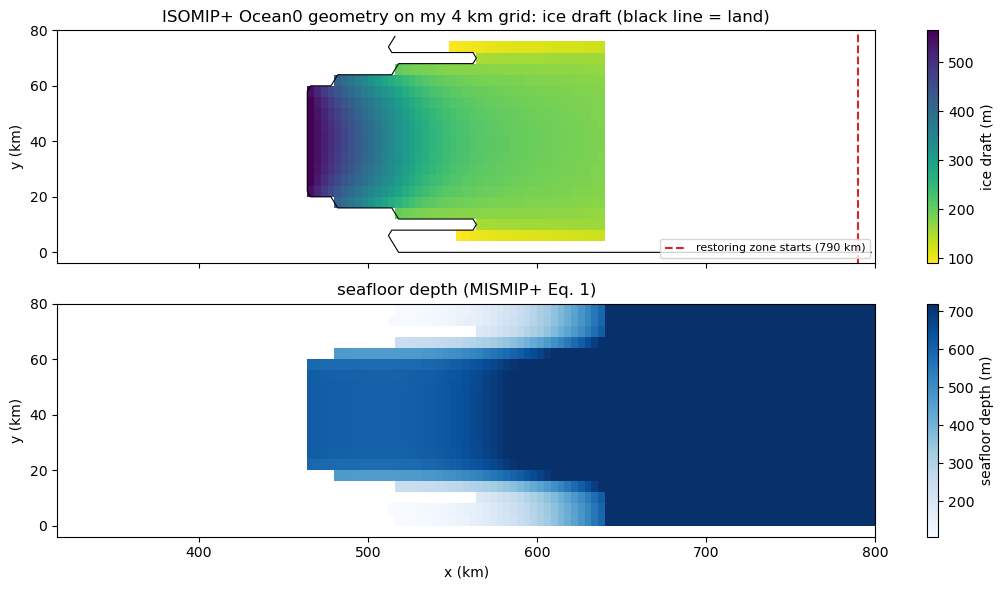

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
xe = np.arange(316e3, 800e3 + 1, DX) / 1e3
ye = np.arange(-4e3, 80e3 + 1, DX) / 1e3
d = np.where(draft_m < 0, -draft_m, np.nan)
m0 = axes[0].pcolormesh(xe, ye, d, cmap="viridis_r")
axes[0].contour(xe[:-1] + 2, ye[:-1] + 2, (bathy_m == 0).astype(float), levels=[0.5], colors="k", linewidths=0.8)
axes[0].axvline(X_R0 / 1e3, color="tab:red", ls="--", label="restoring zone starts (790 km)")
fig.colorbar(m0, ax=axes[0], label="ice draft (m)")
axes[0].set_ylabel("y (km)")
axes[0].set_title("ISOMIP+ Ocean0 geometry on my 4 km grid: ice draft (black line = land)")
axes[0].legend(loc="lower right", fontsize=8)
b = np.where(bathy_m < 0, -bathy_m, np.nan)
m1 = axes[1].pcolormesh(xe, ye, b, cmap="Blues")
fig.colorbar(m1, ax=axes[1], label="seafloor depth (m)")
axes[1].set_xlabel("x (km)")
axes[1].set_ylabel("y (km)")
axes[1].set_title("seafloor depth (MISMIP+ Eq. 1)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "07_isoplus_geometry.png"), dpi=150)
plt.show()

## Part B: calibrating Gamma_T and the final run

ISOMIP+ asks for Gamma_T to be tuned until the mean melt rate over the ice where the draft is deeper than 300 m, averaged over the final 6 months, is 30 +/- 2 m/yr (water equivalent, with a year of 365.2422 days). I first ran 1-year runs with four values of Gamma_T (`experiments/isoplus_g*`), then interpolated to the target, and ran a final 2-year run with that value.

In [8]:
SECONDS_PER_YEAR_SPEC = 365.2422 * 86400.0
RHO_FW = 1000.0
deep = (draft_m < -300.0) & (bathy_m < 0)
grid_area = DX * DX
def deep_melt(run, months=6):
    """Mean melt (m/yr water equivalent) over draft < -300 m and the last `months` 30-day means."""
    its = output_iterations(run, "shelfice_monthly")[-months:]
    total = 0.0
    for it in its:
        fw = read_field(run, "shelfice_monthly", "SHIfwFlx", it)
        total += np.mean(-fw[deep]) / RHO_FW * SECONDS_PER_YEAR_SPEC / len(its)
    return total

def melt_series_ice(run):
    its = output_iterations(run, "shelfice_monthly")
    out = []
    for it in its:
        fw = read_field(run, "shelfice_monthly", "SHIfwFlx", it)
        out.append((np.mean(-fw[deep]) / RHO_FW * SECONDS_PER_YEAR_SPEC,
                    np.mean(-fw[(draft_m < 0)]) / RHO_FW * SECONDS_PER_YEAR_SPEC))
    return np.array(its), np.array(out)

def nan_in_log(text):
    # NaN in the model's own output lines; lines starting with "(PID.TID 0000.0001) >" echo the input files
    for line in text.splitlines():
        if "NaN" in line and not line.startswith("(PID.TID 0000.0001) >"):
            return True
    return False

GAMMAS = {"isoplus_g025": 0.025, "isoplus_g050": 0.05, "isoplus_g100": 0.1, "isoplus_g200": 0.2}
calib = {}
for name, gamma in GAMMAS.items():
    run = os.path.join(RUNS, name)
    text = open(os.path.join(run, "output.txt")).read()
    calib[name] = deep_melt(run)
    print(f"{name}: Gamma_T = {gamma:5.3f} | ended normally {'Execution ended Normally' in text} | NaN in log {nan_in_log(text)} | "
          f"deep melt (last 6 months) {calib[name]:.2f} m/yr")
g = np.array(list(GAMMAS.values()))
m = np.array([calib[n] for n in GAMMAS])
slope, intercept = np.polyfit(np.log(g), np.log(m), 1)
print(f"log-log fit through all four runs: melt ~ Gamma_T^{slope:.3f}; it gives 30 m/yr at Gamma_T = "
      f"{np.exp((np.log(30.0) - intercept) / slope):.4f}")
# The relation may bend, so for the final value I interpolate in log-log space between the
# two runs that bracket 30 m/yr.
k = np.where(m < 30.0)[0].max()            # last run below the target (runs are sorted by Gamma_T)
local_slope = (np.log(m[k + 1]) - np.log(m[k])) / (np.log(g[k + 1]) - np.log(g[k]))
gamma_target = np.exp(np.log(g[k]) + (np.log(30.0) - np.log(m[k])) / local_slope)
print(f"between Gamma_T = {g[k]} and {g[k + 1]}: melt ~ Gamma_T^{local_slope:.3f}; Gamma_T for 30 m/yr: {gamma_target:.4f}")
# the final run uses this value rounded to 3 significant figures, written in its data.shelfice
gamma_final = None
for line in open("../experiments/isoplus_final/data.shelfice"):
    if line.strip().startswith("SHELFICEheatTransCoeff"):
        gamma_final = float(line.split("=")[1].strip().rstrip(","))
print(f"Gamma_T used in the final run (experiments/isoplus_final/data.shelfice): {gamma_final}")

isoplus_g025: Gamma_T = 0.025 | ended normally True | NaN in log False | deep melt (last 6 months) 15.72 m/yr
isoplus_g050: Gamma_T = 0.050 | ended normally True | NaN in log False | deep melt (last 6 months) 31.06 m/yr
isoplus_g100: Gamma_T = 0.100 | ended normally True | NaN in log False | deep melt (last 6 months) 50.99 m/yr
isoplus_g200: Gamma_T = 0.200 | ended normally True | NaN in log False | deep melt (last 6 months) 67.46 m/yr
log-log fit through all four runs: melt ~ Gamma_T^0.702; it gives 30 m/yr at Gamma_T = 0.0545
between Gamma_T = 0.025 and 0.05: melt ~ Gamma_T^0.983; Gamma_T for 30 m/yr: 0.0483
Gamma_T used in the final run (experiments/isoplus_final/data.shelfice): 0.0483


The calibration curve: deep melt rate against Gamma_T, with the target band.

exponent between neighbouring runs: [0.983 0.715 0.404]


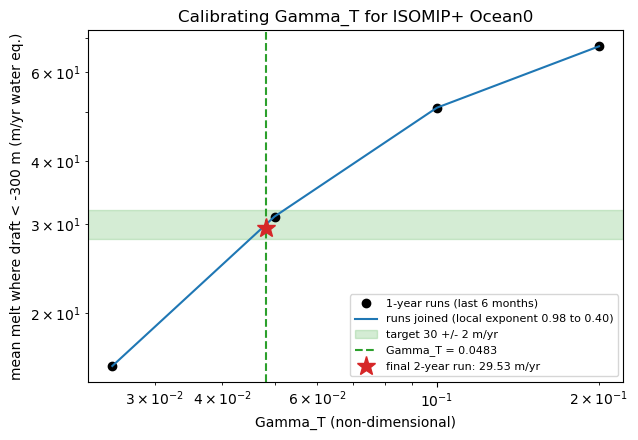

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(g, m, "o", color="k", label="1-year runs (last 6 months)")
local_exponents = np.diff(np.log(m)) / np.diff(np.log(g))
print("exponent between neighbouring runs:", np.round(local_exponents, 3))
ax.loglog(g, m, color="tab:blue", label=f"runs joined (local exponent {local_exponents[0]:.2f} to {local_exponents[-1]:.2f})")
ax.axhspan(28, 32, color="tab:green", alpha=0.2, label="target 30 +/- 2 m/yr")
ax.axvline(gamma_target, color="tab:green", ls="--", label=f"Gamma_T = {gamma_target:.4f}")
FINAL = os.path.join(RUNS, "isoplus_final")
if os.path.exists(os.path.join(FINAL, "output.txt")):
    final_melt = deep_melt(FINAL)
    ax.loglog([gamma_final], [final_melt], "*", ms=14, color="tab:red", label=f"final 2-year run: {final_melt:.2f} m/yr")
ax.set_xlabel("Gamma_T (non-dimensional)")
ax.set_ylabel("mean melt where draft < -300 m (m/yr water eq.)")
ax.set_title("Calibrating Gamma_T for ISOMIP+ Ocean0")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "07_isoplus_calibration.png"), dpi=150)
plt.show()

The final run: its melt time series (deep part and whole shelf), and the melt map averaged over its last 6 months.

final run ended normally: True | NaN in log: False
final run: Gamma_T = 0.0483 | deep melt, last 6 months 29.53 m/yr (target 30 +/- 2) | 6 months before 29.53 m/yr | whole-shelf mean, last 6 months 10.79 m/yr


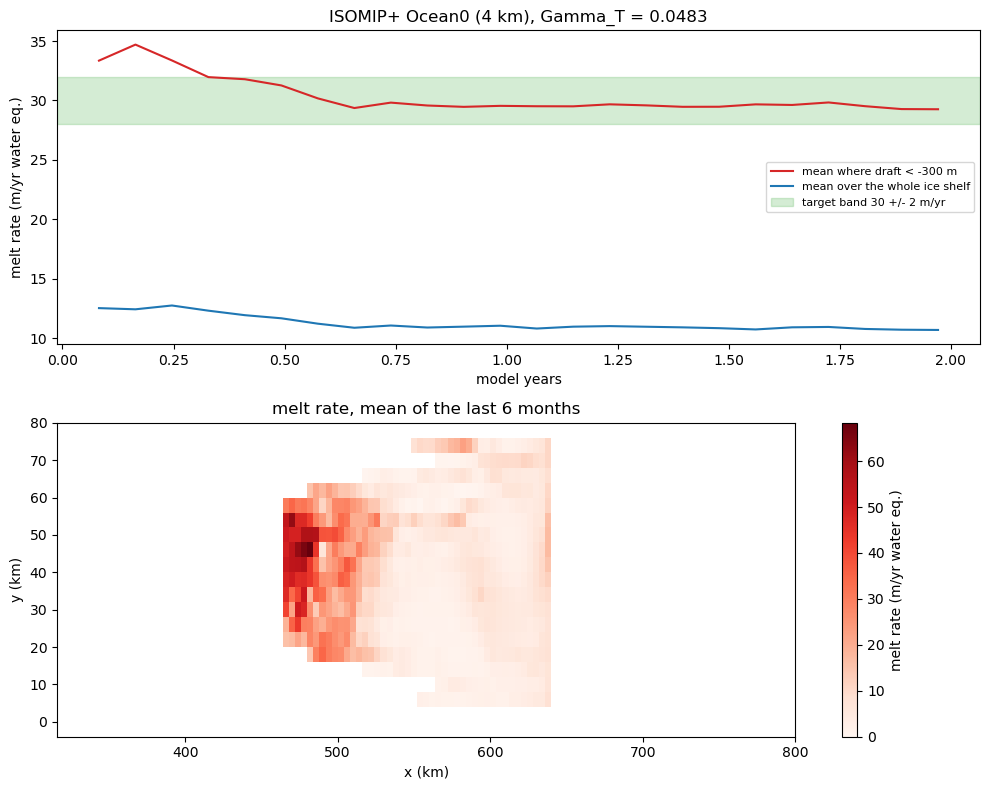

largest local melt 68.3 m/yr, smallest -0.15 m/yr


In [10]:
text = open(os.path.join(FINAL, "output.txt")).read()
print("final run ended normally:", "Execution ended Normally" in text, "| NaN in log:", nan_in_log(text))
its, series = melt_series_ice(FINAL)
days = np.array(its) * 300.0 / 86400.0          # deltaT = 300 s
final_deep = deep_melt(FINAL)
final_all = np.mean(series[-6:, 1])
prev_deep = np.mean(series[-12:-6, 0])
print(f"final run: Gamma_T = {gamma_final} | deep melt, last 6 months {final_deep:.2f} m/yr (target 30 +/- 2) | "
      f"6 months before {prev_deep:.2f} m/yr | whole-shelf mean, last 6 months {final_all:.2f} m/yr")
with open(os.path.join(DATA_DIR, "isoplus_ocean0_results.csv"), "w") as f:
    f.write("run,gamma_t,deep_melt_last6months_m_per_yr_we,whole_shelf_melt_last6months_m_per_yr_we\n")
    for name, gamma in GAMMAS.items():
        f.write(f"{name},{gamma},{calib[name]:.3f},\n")
    f.write(f"isoplus_final,{gamma_final},{final_deep:.3f},{final_all:.3f}\n")

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(days / 365.2422, series[:, 0], color="tab:red", label="mean where draft < -300 m")
axes[0].plot(days / 365.2422, series[:, 1], color="tab:blue", label="mean over the whole ice shelf")
axes[0].axhspan(28, 32, color="tab:green", alpha=0.2, label="target band 30 +/- 2 m/yr")
axes[0].set_xlabel("model years")
axes[0].set_ylabel("melt rate (m/yr water eq.)")
axes[0].set_title(f"ISOMIP+ Ocean0 (4 km), Gamma_T = {gamma_final}")
axes[0].legend(fontsize=8)
its6 = output_iterations(FINAL, "shelfice_monthly")[-6:]
mm = np.zeros(draft_m.shape)
for it in its6:
    mm += -read_field(FINAL, "shelfice_monthly", "SHIfwFlx", it) / RHO_FW * SECONDS_PER_YEAR_SPEC / len(its6)
mm = np.where(draft_m < 0, mm, np.nan)
xe = np.arange(316e3, 800e3 + 1, DX) / 1e3
ye = np.arange(-4e3, 80e3 + 1, DX) / 1e3
mesh = axes[1].pcolormesh(xe, ye, mm, cmap="Reds", vmin=0)
fig.colorbar(mesh, ax=axes[1], label="melt rate (m/yr water eq.)")
axes[1].set_xlabel("x (km)")
axes[1].set_ylabel("y (km)")
axes[1].set_title("melt rate, mean of the last 6 months")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "07_isoplus_final.png"), dpi=150)
plt.show()
print(f"largest local melt {np.nanmax(mm):.1f} m/yr, smallest {np.nanmin(mm):.2f} m/yr")

## Comparison with the literature

ISOMIP+ fixes the melt rate (30 +/- 2 m/yr over draft deeper than 300 m) and lets each model find the Gamma_T that gives it, so the interesting numbers are the Gamma_T needed and the whole-shelf melt. Asay-Davis et al. (2016) suggest a first guess of Gamma_T = 2.2e-2 from their test runs, and say that the POP2x model needed about 0.11 for Ocean0. I compare my calibrated value with both.

In [11]:
GAMMA_GUESS = 2.2e-2      # suggested starting value in Asay-Davis et al. (2016)
GAMMA_POP2X = 0.11        # value POP2x needed for Ocean0, quoted in the same paper
print(f"my calibrated Gamma_T: {gamma_final} | {gamma_final / GAMMA_GUESS:.1f} times the suggested first guess | "
      f"{gamma_final / GAMMA_POP2X:.2f} times the POP2x value")
print(f"melt at the first guess, extended from the two lowest runs (slope {local_slope:.3f}): "
      f"{m[0] * (GAMMA_GUESS / g[0]) ** local_slope:.1f} m/yr")

my calibrated Gamma_T: 0.0483 | 2.2 times the suggested first guess | 0.44 times the POP2x value
melt at the first guess, extended from the two lowest runs (slope 0.983): 13.9 m/yr


## Deviations from the ISOMIP+ Ocean0 specification

Every place where my setup differs from Asay-Davis et al. (2016), and why:

1. Resolution: 4 km horizontal grid instead of the 2 km "common" (COM) resolution, to keep each run near an hour on one laptop core. The 36 layers of 20 m follow the specification.
2. Melt formula: MITgcm's velocity-dependent option follows Holland and Jenkins (1999), not the ISOMIP+ form. I changed a copy of `shelfice_thermodynamics.F` (in `experiments/isomip_plus_code/`, every change commented) so that gamma_T = Gamma_T u* and gamma_S = Gamma_S u*, with u*^2 = Cd (u^2 + u_tidal^2), u_tidal = 0.01 m/s and Cd = 2.5e-3 (Eqs. 24-27), and used the ISOMIP+ liquidus coefficients (-0.0573, 0.0832, -7.53e-8 per Pa). The original code's conversion of potential to in-situ temperature (for the nonlinear equation of state) is switched off, because ISOMIP+ uses a linear equation of state.
3. Bedrock: I used the bedrock in the official geometry file, averaged onto 4 km cells. It differs from the analytic MISMIP+ formula (Eq. 1) by up to about 100 m in places where the file sits at the -720 m floor (see Part A).
4. Grounded cells: a 4 km cell is land if more than half of its 1 km cells are grounded.
5. Minimum water column: floating cells with less than 40 m of water under the ice are made land (50 cells). The paper leaves this to the modeller.
6. Partial cells: `hFacMin = 0.2` (cells at least 20% open). With 0.1, very thin cells under the ice made the run blow up within 10 days (vertical CFL number 1.38 in thin partial cells).
7. Time step: 300 s, for the same reason.
8. Advection: a flux-limited scheme (33) for temperature and salinity, to avoid overshoots near the ice; the paper does not prescribe a scheme.
9. Boundary layer: the melt uses temperature, salinity and velocity averaged over one cell thickness under the ice (`SHELFICEboundaryLayer`, Losch 2008); the paper allows each model its own approach.
10. Fresh water: the melt water is added as a virtual salt flux, not as volume, so the ice cavity's water volume does not change.
11. Restoring: the rate rises linearly from 0 at 790 km to 10 per day at 800 km (Eq. 20), but at 4 km only two cell centres lie in the zone, so the mask is 0.4 and 0.8 there (rbcs tau = 0.1 day).
12. Averaging: the "last 6 months" are the last six 30-day means (180 days), not 6 calendar months of 365.2422/12 days.
13. Run length: the final run is 2 years, the minimum that ISOMIP+ asks for; the calibration runs are 1 year.